In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn import linear_model

In [2]:
df= pd.read_csv(r'C:\New folder (2)\ig-reel-performance-model\instagram_reels_dataset.csv')
df

,video_length_sec,editing_quality_score,posting_hour,hashtag_count,follower_count,caption_length,engagement_rate
0,59,4.9,10,4,115574,148,7.30
1,22,7.6,8,11,25060,149,6.20
2,79,1.4,4,11,77675,292,4.46
3,68,6.1,13,18,87466,142,5.38
4,28,2.4,2,29,100932,159,4.58
...,...,...,...,...,...,...,...
395,8,4.4,9,25,81771,120,5.94
396,23,9.3,6,23,127756,19,6.52
397,68,7.5,2,26,26360,74,5.42
398,71,1.4,2,17,17833,242,0.91


In [3]:
from sklearn import model_selection
x=df[['video_length_sec','editing_quality_score','posting_hour','hashtag_count','follower_count','caption_length']]
y=df['engagement_rate']
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,y,test_size=0.3, random_state=45)

In [4]:
lr= linear_model.LinearRegression()
lr.fit(x_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0. , 0.55, 0.25, 0.04,-0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['video_length_sec','editing_quality_score','posting_hour','hashtag_count', 'follower_count','caption_length']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4794
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [5]:
lr.predict(x_test)

array([10.12894047,  4.55888843, 11.79822893,  2.87837633,  7.39328065,
        7.4136494 ,  9.05393523,  7.39175661,  6.67046836,  2.75570614,
        6.9685266 ,  9.84447498,  5.35369687,  5.40556394,  9.29190871,
        3.61311835,  6.48380971,  8.15323479,  4.84108236,  9.17162316,
        3.87069407,  8.91515423,  6.24209663,  9.6142632 ,  5.88277109,
        5.70025203,  7.80875182, 12.19311175,  6.80498802,  2.18289134,
        7.47361865,  4.17830857,  4.93796826,  7.44146438,  7.31236134,
        7.23539048,  7.54021549,  5.76132979,  4.54563196,  5.27684167,
        7.44427601,  8.71806883,  7.92733515,  6.5519945 ,  3.43838232,
        8.24498321, 10.20217505,  6.41844168,  9.94130923,  9.00624392,
       10.93067287, 10.99383485,  4.19694113,  5.70228753, 10.19977717,
        7.91203276, 11.4920644 ,  8.92182784, 10.6176694 ,  4.71882452,
        8.34047815,  8.26632285,  5.0319457 ,  7.78622629,  3.60923437,
       11.5524542 ,  6.62296268,  9.8876259 ,  8.0396185 , 10.13

In [6]:
lr.score(x_test,y_test)

0.7071251148684041

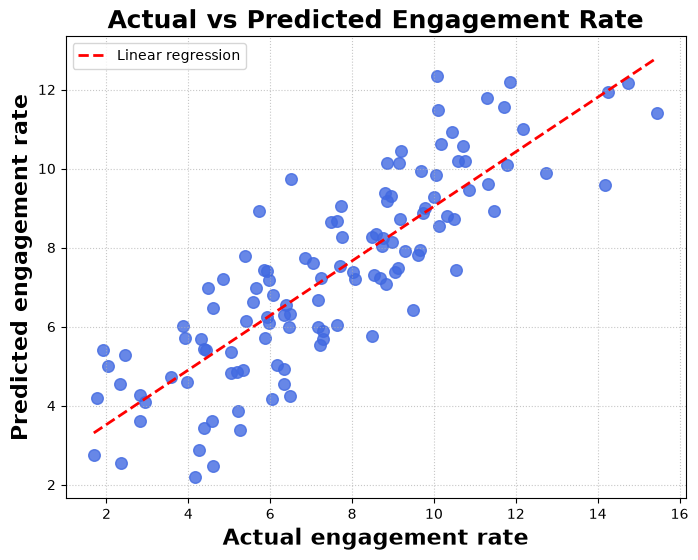

In [8]:
y_pred = lr.predict(x_test)

plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, color='royalblue', s=70, alpha=0.8, marker='o')

m, b = np.polyfit(y_test, y_pred, 1)
line_x = np.linspace(y_test.min(), y_test.max(), 100)
line_y = m * line_x + b

plt.plot(line_x, line_y, color='red', linestyle='--', linewidth=2, label='Linear regression')
plt.xlabel('Actual engagement rate', fontsize=16, fontweight='bold')
plt.ylabel('Predicted engagement rate', fontsize=16, fontweight='bold')
plt.title('Actual vs Predicted Engagement Rate', fontsize=18, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()


In [9]:
from sklearn import linear_model
lr= linear_model.LinearRegression()
lr.fit(df[['video_length_sec','editing_quality_score','posting_hour','hashtag_count','follower_count','caption_length']], df['engagement_rate'])


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](6,)","[-0. , 0.55, 0.26, 0.04,-0. , 0. ]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](6,)","['video_length_sec','editing_quality_score','posting_hour','hashtag_count', 'follower_count','caption_length']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.6259
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,6
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(6)


In [10]:
lr.predict([[30,8,12,4,1000,25]])

c:\Users\HP\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\sklearn\utils\validation.py:2827: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


array([8.23646714])

In [11]:
lr.score(df[['video_length_sec','editing_quality_score','posting_hour','hashtag_count','follower_count','caption_length']], df['engagement_rate'])

0.6840214285062172

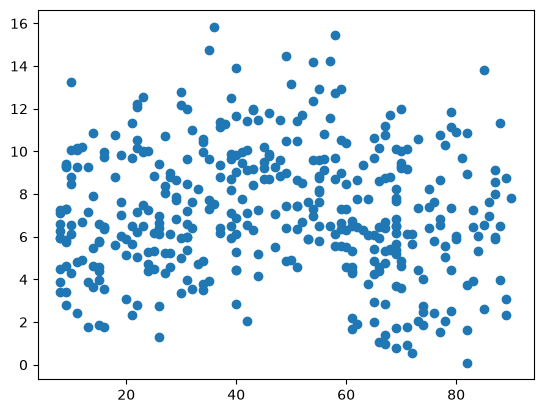

In [12]:
plt.scatter(df['video_length_sec'], df['engagement_rate'])

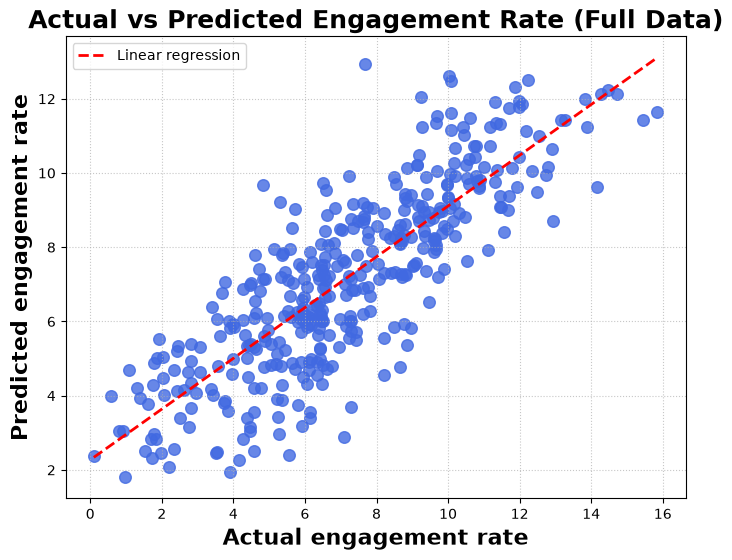

In [16]:
features = ['video_length_sec','editing_quality_score','posting_hour','hashtag_count','follower_count','caption_length']
y_actual = df['engagement_rate']
y_pred_full = lr.predict(df[features])

plt.figure(figsize=(8, 6))
plt.scatter(y_actual, y_pred_full, color='royalblue', s=70, alpha=0.8, marker='o')

m_full, b_full = np.polyfit(y_actual, y_pred_full, 1)
line_x = np.linspace(y_actual.min(), y_actual.max(), 100)
line_y = m_full * line_x + b_full
plt.plot(line_x, line_y, color='red', linestyle='--', linewidth=2, label='Linear regression')

plt.xlabel('Actual engagement rate', fontsize=16, fontweight='bold')
plt.ylabel('Predicted engagement rate', fontsize=16, fontweight='bold')
plt.title('Actual vs Predicted Engagement Rate (Full Data)', fontsize=18, fontweight='bold')
plt.grid(True, linestyle=':', alpha=0.7)
plt.legend()
plt.show()